# Constant Oracle Test

# Deutsch-Jozsa: Constant Oracle Testing

**Objective:** Implement and verify a Constant Oracle within the Deutsch-Jozsa algorithm framework.

**Theory:**
A Constant Oracle is a black-box function that returns the exact same value (either 0 or 1) regardless of the input. 
In the quantum realm, if we pass an $n$-qubit superposition through a Constant Oracle and then apply interference (Hadamard gates), the phase kickback will perfectly destructively interfere for all states except $|00...0\rangle$. 

Therefore, a successfully implemented Constant Oracle will **always** result in a measurement of all zeros.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

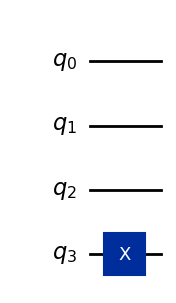

In [2]:
def build_constant_oracle(n: int) -> QuantumCircuit:
    """
    Builds an n-qubit constant oracle.
    In this case, it applies an X gate to the ancilla to represent f(x) = 1 for all x.
    """
    oracle = QuantumCircuit(n + 1, name="Constant Oracle")
    
    # We flip the output qubit (ancilla). It ignores the input qubits entirely.
    oracle.x(n)
    
    return oracle

# Visualize a 3-qubit constant oracle
n_qubits = 3
constant_oracle = build_constant_oracle(n_qubits)
display(constant_oracle.draw('mpl'))

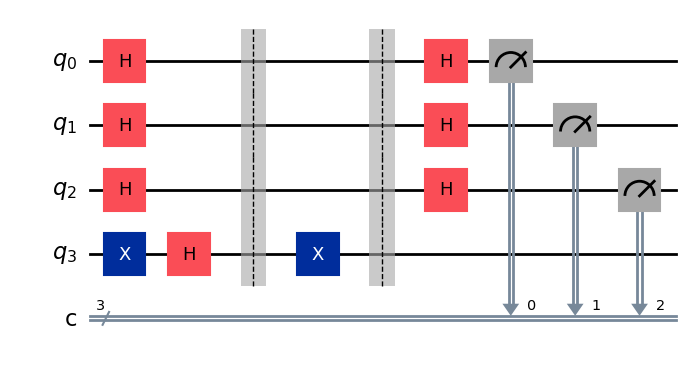

In [3]:
def deutsch_jozsa_circuit(oracle: QuantumCircuit, n: int) -> QuantumCircuit:
    """Wraps an oracle in the Deutsch-Jozsa Hadamard sandwich."""
    qc = QuantumCircuit(n + 1, n)
    
    # 1. Prepare the ancilla (output) qubit in the |1> state
    qc.x(n)
    
    # 2. Apply H-gates to all qubits (inputs enter superposition, ancilla enters |-> state)
    qc.h(range(n + 1))
    qc.barrier()
    
    # 3. Append the Oracle
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 4. Apply H-gates to the input register to cause interference
    qc.h(range(n))
    
    # 5. Measure the input register
    qc.measure(range(n), range(n))
    
    return qc

# Build the full circuit using our constant oracle
dj_constant_circuit = deutsch_jozsa_circuit(constant_oracle, n_qubits)
display(dj_constant_circuit.draw('mpl'))

Constant Oracle Output: {'000': 1024}


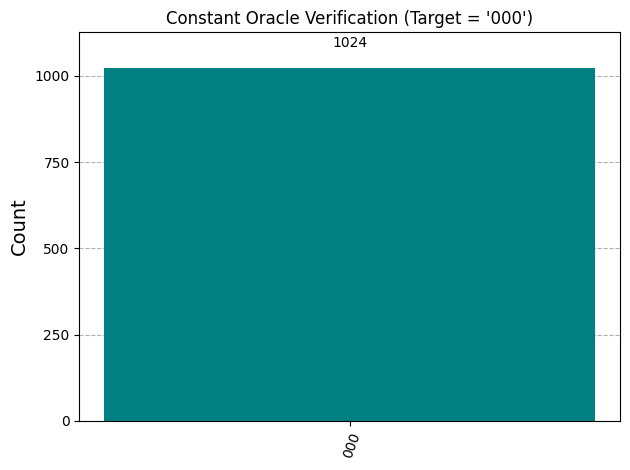

In [4]:
# Initialize the modern V2 Sampler
sampler = StatevectorSampler()

# Execute the circuit over 1024 shots
job = sampler.run([dj_constant_circuit], shots=1024)
pub_result = job.result()[0]

# Extract counts from the classical register
counts = pub_result.data.c.get_counts()

print(f"Constant Oracle Output: {counts}")

# Verification: The result MUST be exactly '000' with 100% probability.
display(plot_histogram(counts, title="Constant Oracle Verification (Target = '000')", color='teal'))